# Augmented Protocol: Activity Dataset Only

Unsupervised REINFORCE training on Activity-only subset (43 videos, homogeneous domain).
No ground truth required during training - rewards from diversity + representativeness only.
Test on full TVSum & SumMe with F1-score computation and comprehensive visualizations.

In [1]:
from pathlib import Path
import os
import sys
import numpy as np
import torch
import torch.nn as nn
from torch.distributions import Bernoulli
from torch.optim import lr_scheduler
import h5py
import json
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
import re
from datetime import datetime

# Paths
CUSTOM_CODE_DIR = Path("/kaggle/input/datasets/ayabenmansour12/video-sum-code-augmented/pytorch-vsumm-reinforce-augmented")
CUSTOM_DATA_BASE = "/kaggle/input/datasets/mariahadjmessaoud/vs-embeddings"

TEST_DATASETS = {
    'dinov2': {'tvsum': "/kaggle/input/datasets/mariahadjmessaoud/tvsum-and-summe-embeddings/h5_files/h5_files/eccv16_dataset_tvsum_dinov2_vitl14.h5",
               'summe': "/kaggle/input/datasets/mariahadjmessaoud/tvsum-and-summe-embeddings/h5_files/h5_files/eccv16_dataset_summe_dinov2_vitl14.h5"},
    'clip_rn50x64': {'tvsum': "/kaggle/input/datasets/mariahadjmessaoud/tvsum-and-summe-embeddings/h5_files/h5_files/eccv16_dataset_tvsum_clip_rn50x64.h5",
                     'summe': "/kaggle/input/datasets/mariahadjmessaoud/tvsum-and-summe-embeddings/h5_files/h5_files/eccv16_dataset_summe_clip_rn50x64.h5"},
    'clip_vitl14': {'tvsum': "/kaggle/input/datasets/mariahadjmessaoud/tvsum-and-summe-embeddings/h5_files/h5_files/eccv16_dataset_tvsum_clip_vitl14.h5",
                    'summe': "/kaggle/input/datasets/mariahadjmessaoud/tvsum-and-summe-embeddings/h5_files/h5_files/eccv16_dataset_summe_clip_vitl14.h5"},
}

EMBEDDINGS = {
    'dinov2': {'folder': 'embeddings_DINOv2/embeddings_DINOv2', 'input_dim': 1024},
    'clip_rn50x64': {'folder': 'embeddings_clip_rn50x64/embeddings_clip_rn50x64', 'input_dim': 1024},
    'clip_vitl14': {'folder': 'embeddings_clip_vitl14/embeddings_clip_vitl14', 'input_dim': 768},
}

SEED = 1
MAX_EPOCHS = 60
GPU_ID = '0'
TRAIN_CATEGORY = 'Activity'  # Train on Activity only
OUT_BASE = Path('/kaggle/working/augmented_activity_results')
OUT_BASE.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(CUSTOM_CODE_DIR))

print('Setup complete. Training category:', TRAIN_CATEGORY)

Setup complete. Training category: Activity


In [2]:
from models import DSN
from rewards import compute_reward
import vsum_tools

torch.manual_seed(SEED)
np.random.seed(SEED)
os.environ['CUDA_VISIBLE_DEVICES'] = GPU_ID
use_gpu = torch.cuda.is_available()

if use_gpu:
    torch.cuda.manual_seed_all(SEED)
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("CPU mode")

print(f"PyTorch version: {torch.__version__}")

GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
PyTorch version: 2.10.0+cu128


In [3]:
def load_npz_embeddings_category(data_base, embedding_config, category_filter=None):
    """Load NPZ embeddings from specific category folder."""
    emb_path = Path(data_base) / embedding_config['folder']
    videos = {}
    
    for category_dir in sorted(emb_path.iterdir()):
        if not category_dir.is_dir():
            continue
        
        # Filter by category if specified
        if category_filter and category_dir.name != category_filter:
            continue
        
        print(f"  Loading {category_dir.name}...")
        
        for npz_file in sorted(category_dir.glob('*.npz')):
            data = np.load(npz_file, allow_pickle=True)
            if 'features' in data:
                feat = data['features']
            elif 'embeddings' in data:
                feat = data['embeddings']
            else:
                feat = data[list(data.keys())[0]]
            videos[npz_file.stem] = torch.from_numpy(feat).float()
    
    print(f"  Loaded {len(videos)} videos")
    return videos

# Load training data for all embeddings (Activity category only)
train_data = {}
for emb_name, cfg in EMBEDDINGS.items():
    print(f"\nLoading {emb_name} ({TRAIN_CATEGORY})...")
    train_data[emb_name] = load_npz_embeddings_category(CUSTOM_DATA_BASE, cfg, category_filter=TRAIN_CATEGORY)
    
print("\nTraining data loaded")


Loading dinov2 (Activity)...
  Loading Activity...
  Loaded 77 videos

Loading clip_rn50x64 (Activity)...
  Loading Activity...
  Loaded 77 videos

Loading clip_vitl14 (Activity)...
  Loading Activity...
  Loaded 77 videos

Training data loaded


In [4]:
def train_unsupervised(model, videos_dict, input_dim, optimizer, scheduler, emb_name, num_epochs=60):
    """Unsupervised REINFORCE training on NPZ embeddings."""
    model.train()
    baselines = {key: 0.0 for key in videos_dict.keys()}
    reward_history = []
    
    for epoch in range(num_epochs):
        epoch_rewards = []
        video_keys = list(videos_dict.keys())
        np.random.shuffle(video_keys)
        
        for video_key in video_keys:
            features = videos_dict[video_key]
            seq = features.unsqueeze(0)
            if use_gpu:
                seq = seq.cuda()
            
            probs = model(seq)
            
            cost = 0.01 * (probs.mean() - 0.5) ** 2
            
            m = Bernoulli(probs)
            episode_rewards = []
            
            for _ in range(5):
                actions = m.sample()
                log_probs = m.log_prob(actions)
                reward = compute_reward(seq, actions, use_gpu=use_gpu)
                expected_reward = log_probs.mean() * (reward - baselines[video_key])
                cost -= expected_reward
                episode_rewards.append(reward.item())
            
            optimizer.zero_grad()
            cost.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            
            baselines[video_key] = 0.9 * baselines[video_key] + 0.1 * np.mean(episode_rewards)
            epoch_rewards.append(np.mean(episode_rewards))
        
        epoch_reward = np.mean(epoch_rewards)
        reward_history.append(epoch_reward)
        print(f"  Epoch {epoch+1}/{num_epochs}: reward={epoch_reward:.4f}")
        
        if scheduler is not None:
            scheduler.step()
    
    return reward_history

train_models = {}
all_train_rewards = {}

for emb_name, cfg in EMBEDDINGS.items():
    print(f"\n===== Training {emb_name} ({TRAIN_CATEGORY}) =====")
    
    model = DSN(in_dim=cfg['input_dim'], hid_dim=256, num_layers=1, cell='lstm')
    if use_gpu:
        model = nn.DataParallel(model).cuda()
    
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-5, weight_decay=1e-5)
    scheduler = lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)
    
    reward_history = train_unsupervised(model, train_data[emb_name], cfg['input_dim'], 
                                       optimizer, scheduler, emb_name, MAX_EPOCHS)
    
    out_dir = OUT_BASE / f"train_{emb_name}"
    out_dir.mkdir(parents=True, exist_ok=True)
    
    model_state = model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict()
    torch.save(model_state, out_dir / f'model_epoch{MAX_EPOCHS}.pth.tar')
    
    train_models[emb_name] = out_dir
    all_train_rewards[emb_name] = reward_history
    
    print(f"Model saved: {out_dir}")

print("\nTraining complete")


===== Training dinov2 (Activity) =====


/kaggle/input/datasets/ayabenmansour12/video-sum-code-augmented/pytorch-vsumm-reinforce-augmented/rewards.py:47: UserWarning: This overload of addmm_ is deprecated:
	addmm_(Number beta, Number alpha, Tensor mat1, Tensor mat2)
Consider using one of the following signatures instead:
	addmm_(Tensor mat1, Tensor mat2, *, Number beta = 1, Number alpha = 1) (Triggered internally at /pytorch/torch/csrc/utils/python_arg_parser.cpp:1862.)
  dist_mat.addmm_(1, -2, _seq, _seq.t())


  Epoch 1/60: reward=0.4109
  Epoch 2/60: reward=0.4112
  Epoch 3/60: reward=0.4109
  Epoch 4/60: reward=0.4107
  Epoch 5/60: reward=0.4112
  Epoch 6/60: reward=0.4120
  Epoch 7/60: reward=0.4109
  Epoch 8/60: reward=0.4113
  Epoch 9/60: reward=0.4119
  Epoch 10/60: reward=0.4108
  Epoch 11/60: reward=0.4124
  Epoch 12/60: reward=0.4116
  Epoch 13/60: reward=0.4109
  Epoch 14/60: reward=0.4115
  Epoch 15/60: reward=0.4109
  Epoch 16/60: reward=0.4117
  Epoch 17/60: reward=0.4119
  Epoch 18/60: reward=0.4117
  Epoch 19/60: reward=0.4111
  Epoch 20/60: reward=0.4116
  Epoch 21/60: reward=0.4110
  Epoch 22/60: reward=0.4126
  Epoch 23/60: reward=0.4124
  Epoch 24/60: reward=0.4120
  Epoch 25/60: reward=0.4122
  Epoch 26/60: reward=0.4119
  Epoch 27/60: reward=0.4120
  Epoch 28/60: reward=0.4123
  Epoch 29/60: reward=0.4127
  Epoch 30/60: reward=0.4131
  Epoch 31/60: reward=0.4129
  Epoch 32/60: reward=0.4120
  Epoch 33/60: reward=0.4126
  Epoch 34/60: reward=0.4126
  Epoch 35/60: reward=0

In [5]:
def evaluate_on_dataset(model, h5_path, dataset_name, emb_name, metric='avg', use_gpu=True):
    """Evaluate on full test dataset (TVSum or SumMe)."""
    model.eval()
    dataset = h5py.File(h5_path, 'r')
    f_scores = []
    
    video_keys = list(dataset.keys())
    print(f"  Evaluating on {len(video_keys)} videos...")
    
    with torch.no_grad():
        for idx, video_key in enumerate(video_keys):
            features = dataset[video_key]['features'][...]
            seq = torch.from_numpy(features).unsqueeze(0).float()
            if use_gpu:
                seq = seq.cuda()
            
            probs = model(seq)
            probs = probs.data.cpu().squeeze().numpy()
            
            cps = dataset[video_key]['change_points'][...]
            num_frames = dataset[video_key]['n_frames'][()]
            nfps = dataset[video_key]['n_frame_per_seg'][...].tolist()
            picks = dataset[video_key]['picks'][...]
            user_summary = dataset[video_key]['user_summary'][...]
            
            machine_summary = vsum_tools.generate_summary(probs, cps, num_frames, nfps, picks)
            f_score, _, _ = vsum_tools.evaluate_summary(machine_summary, user_summary, metric)
            f_scores.append(f_score)
            
            if (idx + 1) % 10 == 0:
                print(f"    Processed {idx+1}/{len(video_keys)}")
    
    dataset.close()
    mean_fscore = np.mean(f_scores)
    return mean_fscore, f_scores

eval_results = {}

for emb_name, cfg in EMBEDDINGS.items():
    print(f"\n===== Evaluating {emb_name} =====")
    
    model = DSN(in_dim=cfg['input_dim'], hid_dim=256, num_layers=1, cell='lstm')
    if use_gpu:
        model = nn.DataParallel(model).cuda()
    
    ckpt_path = train_models[emb_name] / f'model_epoch{MAX_EPOCHS}.pth.tar'
    state_dict = torch.load(ckpt_path)
    if isinstance(model, nn.DataParallel):
        model.module.load_state_dict(state_dict)
    else:
        model.load_state_dict(state_dict)
    
    eval_results[emb_name] = {}
    
    print(f"\n  TVSum:")
    tvsum_h5 = TEST_DATASETS[emb_name]['tvsum']
    tvsum_score, tvsum_scores = evaluate_on_dataset(model, tvsum_h5, 'TVSum', emb_name, metric='avg', use_gpu=use_gpu)
    eval_results[emb_name]['tvsum'] = {'mean': tvsum_score, 'all': tvsum_scores}
    print(f"    Mean F-score: {tvsum_score:.4f}")
    
    print(f"\n  SumMe:")
    summe_h5 = TEST_DATASETS[emb_name]['summe']
    summe_score, summe_scores = evaluate_on_dataset(model, summe_h5, 'SumMe', emb_name, metric='max', use_gpu=use_gpu)
    eval_results[emb_name]['summe'] = {'mean': summe_score, 'all': summe_scores}
    print(f"    Mean F-score: {summe_score:.4f}")

print("\nEvaluation complete")


===== Evaluating dinov2 =====

  TVSum:
  Evaluating on 50 videos...
    Processed 10/50
    Processed 20/50
    Processed 30/50
    Processed 40/50
    Processed 50/50
    Mean F-score: 0.5599

  SumMe:
  Evaluating on 25 videos...
    Processed 10/25
    Processed 20/25
    Mean F-score: 0.4226

===== Evaluating clip_rn50x64 =====

  TVSum:
  Evaluating on 50 videos...
    Processed 10/50
    Processed 20/50
    Processed 30/50
    Processed 40/50
    Processed 50/50
    Mean F-score: 0.5646

  SumMe:
  Evaluating on 25 videos...
    Processed 10/25
    Processed 20/25
    Mean F-score: 0.3960

===== Evaluating clip_vitl14 =====

  TVSum:
  Evaluating on 50 videos...
    Processed 10/50
    Processed 20/50
    Processed 30/50
    Processed 40/50
    Processed 50/50
    Mean F-score: 0.5648

  SumMe:
  Evaluating on 25 videos...
    Processed 10/25
    Processed 20/25
    Mean F-score: 0.3720

Evaluation complete


In [6]:
print("\n" + "="*70)
print("AUGMENTED PROTOCOL - ACTIVITY ONLY RESULTS")
print(f"(Trained unsupervised on {TRAIN_CATEGORY.upper()} videos)")
print("(Tested on full TVSum & SumMe benchmarks)")
print("="*70 + "\n")

rows = []
for emb_name in EMBEDDINGS.keys():
    tvsum_mean = eval_results[emb_name]['tvsum']['mean']
    summe_mean = eval_results[emb_name]['summe']['mean']
    rows.append([emb_name, f"{tvsum_mean*100:.2f}%", f"{summe_mean*100:.2f}%"])

print(tabulate(rows, headers=['Embedding', 'TVSum F-score', 'SumMe F-score'], tablefmt='github'))
print()


AUGMENTED PROTOCOL - ACTIVITY ONLY RESULTS
(Trained unsupervised on ACTIVITY videos)
(Tested on full TVSum & SumMe benchmarks)

| Embedding    | TVSum F-score   | SumMe F-score   |
|--------------|-----------------|-----------------|
| dinov2       | 55.99%          | 42.26%          |
| clip_rn50x64 | 56.46%          | 39.60%          |
| clip_vitl14  | 56.48%          | 37.20%          |



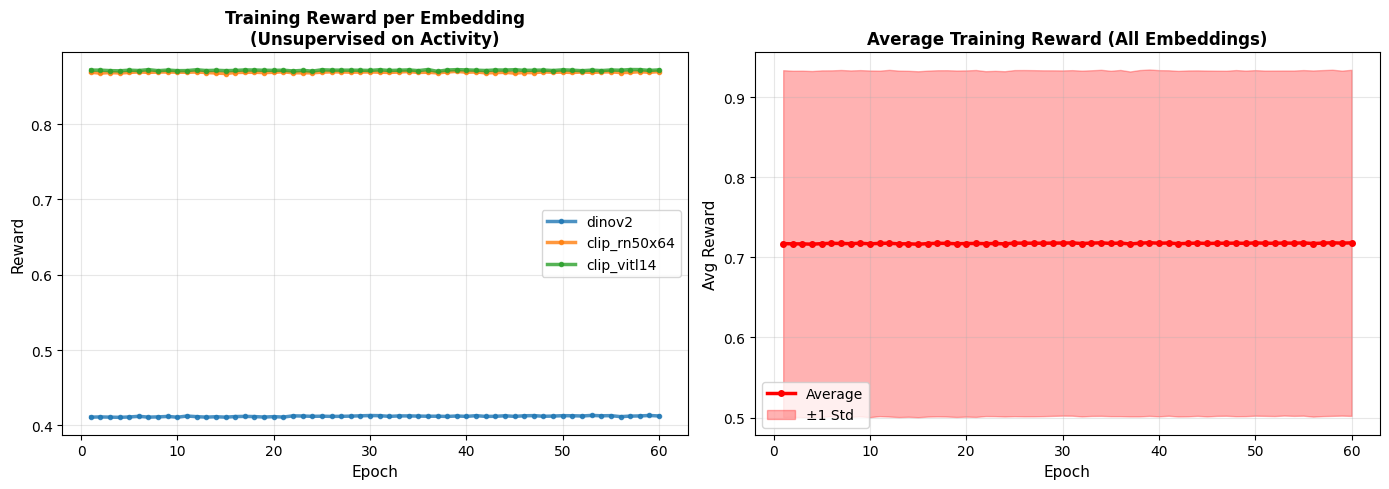

Plot 1 saved


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for emb_name, rewards in all_train_rewards.items():
    epochs = np.arange(1, len(rewards) + 1)
    ax.plot(epochs, rewards, marker='o', label=emb_name, linewidth=2.5, markersize=3, alpha=0.8)

ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Reward', fontsize=11)
ax.set_title(f'Training Reward per Embedding\n(Unsupervised on {TRAIN_CATEGORY})', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

ax = axes[1]
all_rewards = [all_train_rewards[emb] for emb in EMBEDDINGS.keys()]
avg_rewards = np.mean(all_rewards, axis=0)
std_rewards = np.std(all_rewards, axis=0)
epochs = np.arange(1, len(avg_rewards) + 1)

ax.plot(epochs, avg_rewards, color='red', linewidth=2.5, marker='o', markersize=4, label='Average')
ax.fill_between(epochs, avg_rewards - std_rewards, avg_rewards + std_rewards, alpha=0.3, color='red', label='±1 Std')

ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Avg Reward', fontsize=11)
ax.set_title('Average Training Reward (All Embeddings)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_BASE / 'plot_1_training_rewards.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 1 saved")

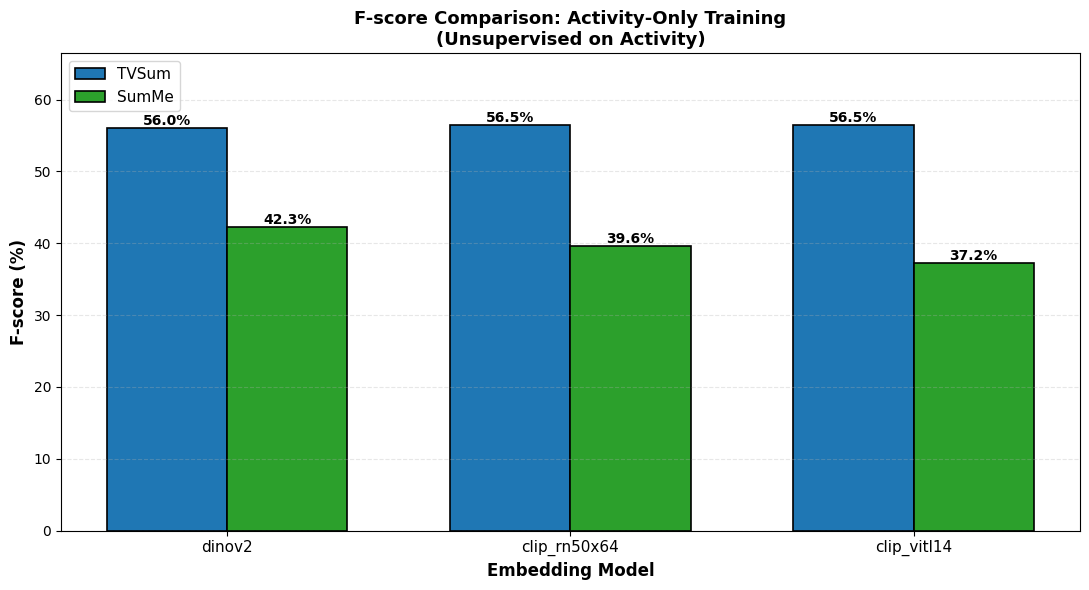

Plot 2 saved


In [8]:
embs = list(EMBEDDINGS.keys())
tvsum_scores = [eval_results[emb]['tvsum']['mean'] * 100 for emb in embs]
summe_scores = [eval_results[emb]['summe']['mean'] * 100 for emb in embs]

x = np.arange(len(embs))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
bars1 = ax.bar(x - width/2, tvsum_scores, width, label='TVSum', color='#1f77b4', edgecolor='black', linewidth=1.2)
bars2 = ax.bar(x + width/2, summe_scores, width, label='SumMe', color='#2ca02c', edgecolor='black', linewidth=1.2)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Embedding Model', fontsize=12, fontweight='bold')
ax.set_ylabel('F-score (%)', fontsize=12, fontweight='bold')
ax.set_title(f'F-score Comparison: Activity-Only Training\n(Unsupervised on {TRAIN_CATEGORY})',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(embs, fontsize=11)
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, axis='y', alpha=0.3, linestyle='--')
ax.set_ylim([0, max(max(tvsum_scores), max(summe_scores)) + 10])

plt.tight_layout()
plt.savefig(OUT_BASE / 'plot_2_comparative_fscore.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 2 saved")

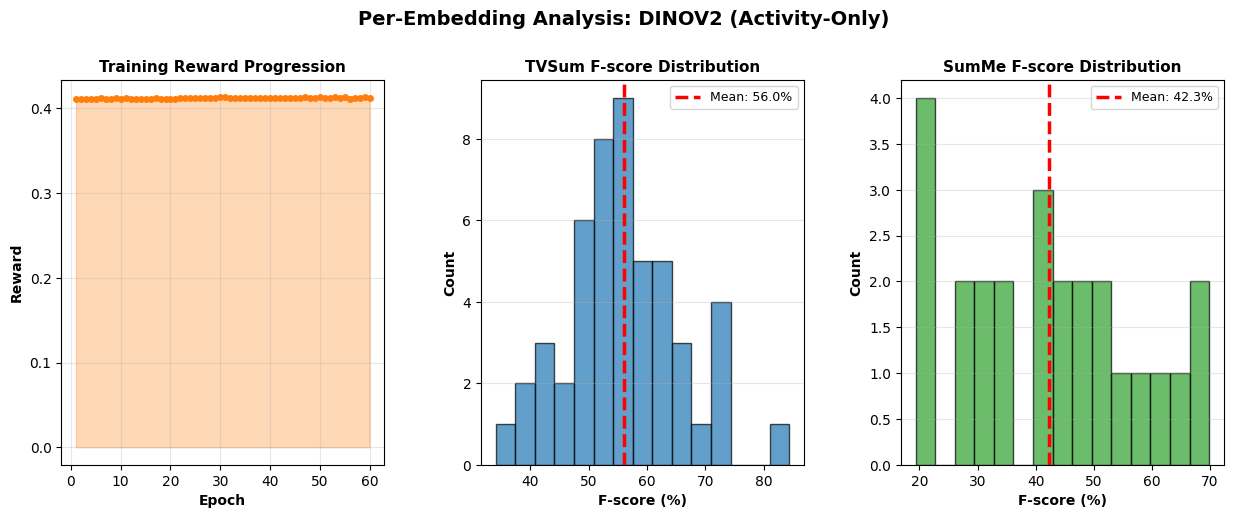

Plot 3 saved (dinov2)


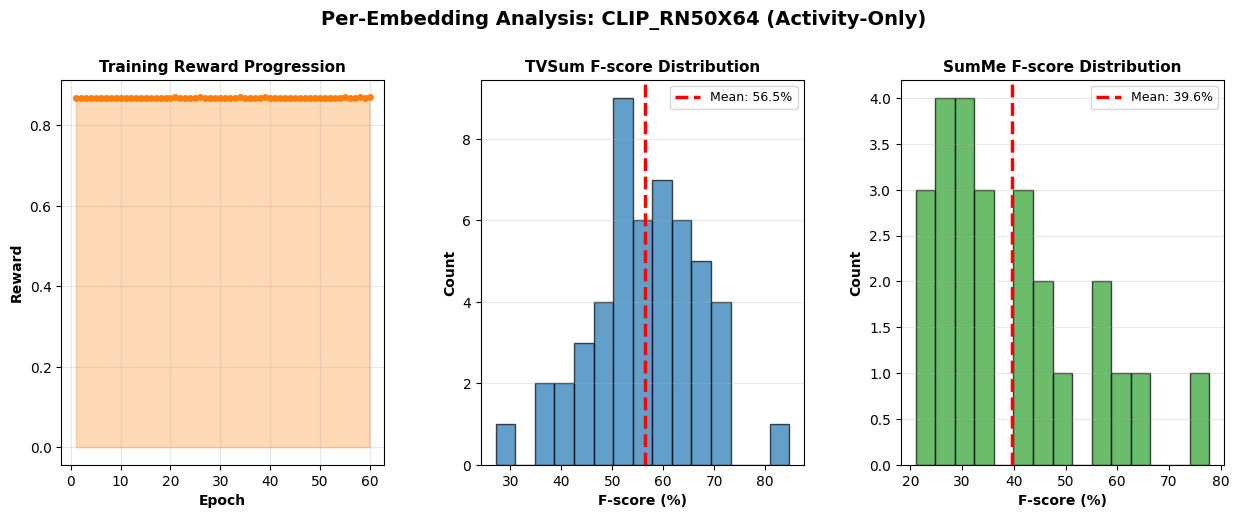

Plot 4 saved (clip_rn50x64)


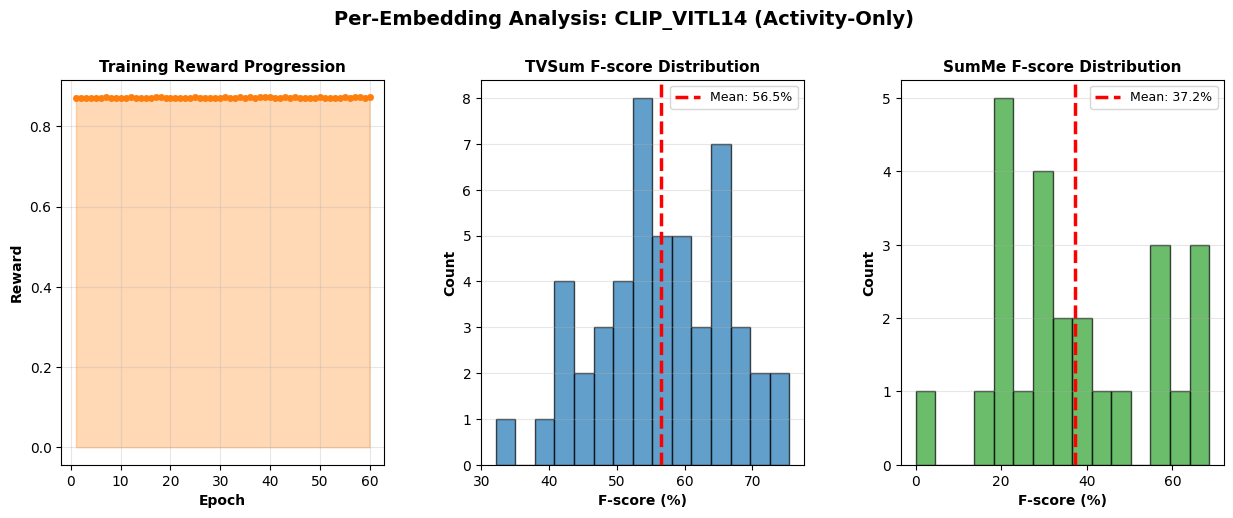

Plot 5 saved (clip_vitl14)


In [9]:
for idx, emb_name in enumerate(EMBEDDINGS.keys(), 1):
    fig = plt.figure(figsize=(15, 5))
    gs = fig.add_gridspec(1, 3, hspace=0.3, wspace=0.3)
    
    ax1 = fig.add_subplot(gs[0, 0])
    rewards = all_train_rewards[emb_name]
    epochs = np.arange(1, len(rewards) + 1)
    ax1.plot(epochs, rewards, color='#ff7f0e', linewidth=2.5, marker='o', markersize=4)
    ax1.fill_between(epochs, rewards, alpha=0.3, color='#ff7f0e')
    ax1.set_xlabel('Epoch', fontsize=10, fontweight='bold')
    ax1.set_ylabel('Reward', fontsize=10, fontweight='bold')
    ax1.set_title('Training Reward Progression', fontsize=11, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    
    ax2 = fig.add_subplot(gs[0, 1])
    tvsum_scores = np.array(eval_results[emb_name]['tvsum']['all']) * 100
    ax2.hist(tvsum_scores, bins=15, color='#1f77b4', alpha=0.7, edgecolor='black')
    ax2.axvline(tvsum_scores.mean(), color='red', linestyle='--', linewidth=2.5, label=f"Mean: {tvsum_scores.mean():.1f}%")
    ax2.set_xlabel('F-score (%)', fontsize=10, fontweight='bold')
    ax2.set_ylabel('Count', fontsize=10, fontweight='bold')
    ax2.set_title('TVSum F-score Distribution', fontsize=11, fontweight='bold')
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3, axis='y')
    
    ax3 = fig.add_subplot(gs[0, 2])
    summe_scores = np.array(eval_results[emb_name]['summe']['all']) * 100
    ax3.hist(summe_scores, bins=15, color='#2ca02c', alpha=0.7, edgecolor='black')
    ax3.axvline(summe_scores.mean(), color='red', linestyle='--', linewidth=2.5, label=f"Mean: {summe_scores.mean():.1f}%")
    ax3.set_xlabel('F-score (%)', fontsize=10, fontweight='bold')
    ax3.set_ylabel('Count', fontsize=10, fontweight='bold')
    ax3.set_title('SumMe F-score Distribution', fontsize=11, fontweight='bold')
    ax3.legend(fontsize=9)
    ax3.grid(True, alpha=0.3, axis='y')
    
    fig.suptitle(f'Per-Embedding Analysis: {emb_name.upper()} (Activity-Only)', fontsize=14, fontweight='bold', y=1.02)
    
    plt.savefig(OUT_BASE / f'plot_{idx+2}_per_embedding_{emb_name}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Plot {idx+2} saved ({emb_name})")

In [10]:
import shutil
import zipfile

results = {
    'protocol': 'augmented_activity_only',
    'date': datetime.now().isoformat(),
    'settings': {
        'training_dataset': f'{TRAIN_CATEGORY}_videos',
        'test_datasets': ['tvsum', 'summe'],
        'max_epochs': MAX_EPOCHS,
        'embeddings': list(EMBEDDINGS.keys()),
    },
    'f_scores': {},
    'training_rewards': {},
}

for emb_name in EMBEDDINGS.keys():
    results['f_scores'][emb_name] = {
        'tvsum': {
            'mean': float(eval_results[emb_name]['tvsum']['mean']),
            'std': float(np.std(eval_results[emb_name]['tvsum']['all'])),
            'all': [float(x) for x in eval_results[emb_name]['tvsum']['all']]
        },
        'summe': {
            'mean': float(eval_results[emb_name]['summe']['mean']),
            'std': float(np.std(eval_results[emb_name]['summe']['all'])),
            'all': [float(x) for x in eval_results[emb_name]['summe']['all']]
        }
    }

for emb_name in EMBEDDINGS.keys():
    results['training_rewards'][emb_name] = [float(x) for x in all_train_rewards[emb_name]]

json_path = OUT_BASE / 'augmented_activity_results.json'
with open(json_path, 'w') as f:
    json.dump(results, f, indent=2)
print(f"Results saved: {json_path}")

zip_path = OUT_BASE / 'augmented_activity_results.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as z:
    z.write(json_path, arcname='results.json')
    for png in OUT_BASE.glob('plot_*.png'):
        z.write(png, arcname=png.name)

print(f"Archive created: {zip_path}")
print(f"\nAll outputs in: {OUT_BASE}")

Results saved: /kaggle/working/augmented_activity_results/augmented_activity_results.json
Archive created: /kaggle/working/augmented_activity_results/augmented_activity_results.zip

All outputs in: /kaggle/working/augmented_activity_results
